# NER Training — IndoBERT Uncased v2 (Root Cause Fixed)
## Named Entity Recognition: Ekstraksi Lokasi dari Laporan Pengaduan Sampah

| Item | Detail |
|---|---|
| **Model** | `indobenchmark/indobert-base-p2` (BERT WordPiece, uncased, ~110M params) |
| **Root Fix** | Ganti ALBERT → BERT agar `word_ids()` bekerja benar + WeightedLossTrainer |
| **Entitas** | LOC (B-LOC, I-LOC) |

---

## Cell 1 · Instalasi Library

In [1]:
!pip install -q seqeval transformers datasets scikit-learn accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Cell 2 · Imports & Konfigurasi Global

In [2]:
import os, json, random, warnings, math
import numpy as np
import torch
import torch.nn as nn
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)
from datasets import Dataset
from seqeval.metrics import (
    f1_score        as seqeval_f1,
    precision_score as seqeval_precision,
    recall_score    as seqeval_recall,
    classification_report as seqeval_report,
)

warnings.filterwarnings("ignore")

CONFIG = {
    # ── Path ──────────────────────────────────────────────────────────────────
    "data_path"  : "/kaggle/input/datasets/jundansaifulhaq/dataset-ner-rev2/dataset_ner_cleaned.txt",
    "output_dir" : "/kaggle/working/ner_bert_uncased_v2",

    # ── Model ─────────────────────────────────────────────────────────────────
    # FIX: indobert-lite-base-p2 (ALBERT, SentencePiece) → indobert-base-p2 (BERT, WordPiece)
    # indobert-base-p2 = BERT uncased (~110M params). WordPiece fast tokenizer
    # mendukung word_ids() 100% akurat, sehingga alignment label B-LOC/I-LOC bekerja benar.
    # Model ini juga uncased → "kaliurang", "Kaliurang", "KALIURANG" diperlakukan sama.
    "model_name" : "indobenchmark/indobert-base-p2",
    "max_length" : 128,      # BERT WordPiece lebih efisien; 128 aman untuk semua kalimat

    # ── Label ─────────────────────────────────────────────────────────────────
    "label2id"   : {"O": 0, "B-LOC": 1, "I-LOC": 2},

    # ── Split ─────────────────────────────────────────────────────────────────
    "test_size"  : 0.10,
    "val_size"   : 0.10,

    # ── Training ──────────────────────────────────────────────────────────────
    "num_epochs"          : 20,    # lebih banyak epoch karena dataset kecil
    "batch_size"          : 16,
    "learning_rate"       : 2e-5,
    "warmup_ratio"        : 0.10,
    "weight_decay"        : 0.01,
    "max_grad_norm"       : 1.0,
    "dropout"             : 0.15,
    "early_stop_patience" : 5,

    "seed" : 42,
}

ID2LABEL   = {v: k for k, v in CONFIG["label2id"].items()}
NUM_LABELS = len(CONFIG["label2id"])

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device    : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Model     : {CONFIG['model_name']}")
print(f"Labels    : {CONFIG['label2id']}")


Device    : cuda
GPU       : Tesla T4
VRAM      : 15.64 GB
Model     : indobenchmark/indobert-base-p2
Labels    : {'O': 0, 'B-LOC': 1, 'I-LOC': 2}


## Cell 3 · Load & Parse Dataset (CoNLL / BIO)

In [3]:
def load_conll(filepath):
    """
    Membaca file CoNLL BIO. Toleran terhadap BOM dan CRLF.
    Mengembalikan list kalimat; setiap kalimat = list of (token, label).
    """
    sentences, current = [], []
    with open(filepath, "r", encoding="utf-8-sig") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                if current:
                    sentences.append(current)
                    current = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    current.append((parts[0], parts[-1]))
    if current:
        sentences.append(current)
    return sentences


all_sentences  = load_conll(CONFIG["data_path"])
all_label_flat = [lbl for sent in all_sentences for _, lbl in sent]
label_counts   = Counter(all_label_flat)
lengths        = [len(s) for s in all_sentences]
total_tokens   = sum(label_counts.values())

print(f"Total kalimat     : {len(all_sentences)}")
print(f"Total token       : {total_tokens:,}")
print(f"Rata-rata panjang : {sum(lengths)/len(lengths):.1f} token")
print(f"Panjang maks      : {max(lengths)} token")
print()
print("Distribusi label:")
for lbl, c in label_counts.most_common():
    bar = "█" * int(c / total_tokens * 50)
    print(f"  {lbl:<8}: {c:>6} ({c/total_tokens*100:5.1f}%) {bar}")


Total kalimat     : 1106
Total token       : 39,073
Rata-rata panjang : 35.3 token
Panjang maks      : 51 token

Distribusi label:
  O       :  35019 ( 89.6%) ████████████████████████████████████████████
  I-LOC   :   2563 (  6.6%) ███
  B-LOC   :   1491 (  3.8%) █


## Cell 4 · Hitung Class Weights

Formula: `weight[label] = sqrt(count_O / count_label)`.
Ini yang menjadi pondasi WeightedLossTrainer — **fix yang benar** untuk class imbalance.


In [4]:
count_O = label_counts.get("O",     1)
count_B = label_counts.get("B-LOC", 1)
count_I = label_counts.get("I-LOC", 1)

CLASS_WEIGHTS_GLOBAL = torch.tensor([
    1.0,
    math.sqrt(count_O / count_B),
    math.sqrt(count_O / count_I),
], dtype=torch.float)

print("Class weights (global, akan di-update setelah split):")
print(f"  O      (idx=0): {CLASS_WEIGHTS_GLOBAL[0]:.4f}")
print(f"  B-LOC  (idx=1): {CLASS_WEIGHTS_GLOBAL[1]:.4f}")
print(f"  I-LOC  (idx=2): {CLASS_WEIGHTS_GLOBAL[2]:.4f}")


Class weights (global, akan di-update setelah split):
  O      (idx=0): 1.0000
  B-LOC  (idx=1): 4.8463
  I-LOC  (idx=2): 3.6964


## Cell 5 · Stratified Split 80 / 10 / 10

In [5]:
def has_loc(sentence):
    return any(lbl in ("B-LOC", "I-LOC") for _, lbl in sentence)

labels_for_split = [1 if has_loc(s) else 0 for s in all_sentences]

train_val_sents, test_sents, tv_lbl, _ = train_test_split(
    all_sentences, labels_for_split,
    test_size=CONFIG["test_size"],
    stratify=labels_for_split,
    random_state=CONFIG["seed"],
)

val_ratio = CONFIG["val_size"] / (1 - CONFIG["test_size"])
tv_strat  = [1 if has_loc(s) else 0 for s in train_val_sents]

train_sents, val_sents = train_test_split(
    train_val_sents,
    test_size=val_ratio,
    stratify=tv_strat,
    random_state=CONFIG["seed"],
)

print("Split:")
for name, split in [("Train", train_sents), ("Val", val_sents), ("Test", test_sents)]:
    n_loc = sum(1 for s in split if has_loc(s))
    print(f"  {name:<6}: {len(split):>5} kalimat | LOC: {n_loc}/{len(split)} ({n_loc/len(split)*100:.1f}%)")

# Update class weights dari training set saja
train_labels_flat = [lbl for sent in train_sents for _, lbl in sent]
train_cnt = Counter(train_labels_flat)
CLASS_WEIGHTS = torch.tensor([
    1.0,
    math.sqrt(train_cnt.get("O", 1) / train_cnt.get("B-LOC", 1)),
    math.sqrt(train_cnt.get("O", 1) / train_cnt.get("I-LOC", 1)),
], dtype=torch.float)
print(f"\nClass weights (dari train set): O={CLASS_WEIGHTS[0]:.3f}, B-LOC={CLASS_WEIGHTS[1]:.3f}, I-LOC={CLASS_WEIGHTS[2]:.3f}")


Split:
  Train :   884 kalimat | LOC: 785/884 (88.8%)
  Val   :   111 kalimat | LOC: 99/111 (89.2%)
  Test  :   111 kalimat | LOC: 99/111 (89.2%)

Class weights (dari train set): O=1.000, B-LOC=4.850, I-LOC=3.695


## Cell 6 · Tokenizer Loading + Sanity Check `word_ids()`

> **FIX KRITIS**: Dua parameter eksplisit ditambahkan:
> - `do_lower_case=True` — pastikan semua token dikonversi ke lowercase sebelum tokenisasi
> - `use_fast=True` — pastikan HuggingFace menggunakan Rust-based fast tokenizer
>
> Setelah load, dilakukan **sanity check `word_ids()`** untuk memverifikasi alignment
> bekerja benar sebelum training dimulai.


In [6]:
print(f"Memuat tokenizer: {CONFIG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(
    CONFIG["model_name"],
    do_lower_case=True,   # FIX: normalisasi lowercase eksplisit
    use_fast=True,        # FIX: pastikan fast tokenizer (wajib untuk word_ids() akurat)
)
print(f"Tokenizer type : {type(tokenizer).__name__}")
print(f"Vocab size     : {tokenizer.vocab_size:,}")
print(f"Is fast?       : {tokenizer.is_fast}")
print()

# ── SANITY CHECK: Pastikan word_ids() bekerja benar ──────────────────────────
# Ini adalah verifikasi yang WAJIB dilakukan sebelum training.
# Jika word_ids() mengembalikan None atau semua None, alignment akan rusak
# dan seluruh training akan sia-sia (F1 = 0).

test_words  = ["jalan", "kaliurang", "km", "10"]
test_labels = ["B-LOC", "I-LOC", "I-LOC", "I-LOC"]

enc      = tokenizer(test_words, is_split_into_words=True, return_tensors=None)
word_ids = enc.word_ids()
subwords = tokenizer.convert_ids_to_tokens(enc["input_ids"])

print("── Sanity Check word_ids() ──────────────────────────────")
print(f"{'Subword':<18} {'word_id':<10} {'Expected label'}")
n_valid = 0
n_invalid = 0
for sw, wid in zip(subwords, word_ids):
    if wid is not None:
        lbl = test_labels[wid] if wid < len(test_labels) else "?"
        n_valid += 1
    else:
        lbl = "SPECIAL/IGNORE"
        n_invalid += 1
    print(f"  {sw:<16} {str(wid):<10} {lbl}")

# Pastikan ada word_id yang valid (bukan semua None)
n_loc_ids = sum(1 for wid in word_ids if wid is not None)
assert n_loc_ids > 0, "FATAL: word_ids() mengembalikan semua None! Tokenizer tidak kompatibel."
print()
print(f"✓ word_ids() bekerja: {n_valid} valid tokens, {n_invalid} special tokens")
print("✓ Alignment label akan bekerja benar")
print()

# ── Demo alignment untuk berbagai kasus casing ────────────────────────────────
print("── Demo Alignment (kasus casing & angka) ───────────────")


def align_labels_with_word_ids(word_ids: list, original_labels: list, label2id: dict) -> list:
    """
    Memetakan label BIO dari level kata ke level sub-word token.

    Rules:
    - Token spesial (word_id is None)   → -100  (diabaikan di CrossEntropy)
    - Sub-word PERTAMA dari kata baru   → label asli kata tersebut
    - Sub-word LANJUTAN (##xxx)         → -100  (diabaikan di CrossEntropy)
    """
    aligned, prev_word_id = [], None
    for word_id in word_ids:
        if word_id is None:
            aligned.append(-100)
        elif word_id != prev_word_id:
            aligned.append(label2id[original_labels[word_id]])
        else:
            aligned.append(-100)
        prev_word_id = word_id
    return aligned


demo_cases = [
    (["Jalan", "Kaliurang", "KM", "10"],             ["B-LOC", "I-LOC", "I-LOC", "I-LOC"]),
    (["jalan", "Kaliurang", "km", "10"],             ["B-LOC", "I-LOC", "I-LOC", "I-LOC"]),
    (["jalan", "kaliurang", "km", "10"],             ["B-LOC", "I-LOC", "I-LOC", "I-LOC"]),
    (["jalan", "Sleman", "Ring", "Road", "Selatan"], ["B-LOC", "I-LOC", "I-LOC", "I-LOC", "I-LOC"]),
    (["jalan", "Kenanga", "RT", "02", "RW", "01"],   ["B-LOC", "I-LOC", "I-LOC", "I-LOC", "I-LOC", "I-LOC"]),
    (["SLB", "N", "2", "Bantul"],                    ["B-LOC", "I-LOC", "I-LOC", "I-LOC"]),
]

all_ok = True
for words, labels in demo_cases:
    enc     = tokenizer(words, is_split_into_words=True,
                        truncation=True, max_length=CONFIG["max_length"])
    wids    = enc.word_ids()
    aligned = align_labels_with_word_ids(wids, labels, CONFIG["label2id"])
    sw      = tokenizer.convert_ids_to_tokens(enc["input_ids"])

    # Hitung berapa label non-O yang terdeteksi (harus sama dengan jumlah kata LOC)
    n_loc_aligned = sum(1 for a in aligned if a in (1, 2))
    n_loc_words   = sum(1 for l in labels if l != "O")

    status = "✓" if n_loc_aligned == n_loc_words else "✗ MISMATCH"
    if n_loc_aligned != n_loc_words:
        all_ok = False
    print(f"  {status} '{' '.join(words)}' → {n_loc_aligned}/{n_loc_words} LOC tokens aligned")

print()
if all_ok:
    print("✓ Semua kasus alignment benar! Training siap dimulai.")
else:
    print("✗ Ada alignment mismatch! Cek tokenizer. JANGAN lanjutkan training.")


Memuat tokenizer: indobenchmark/indobert-base-p2


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer type : BertTokenizer
Vocab size     : 30,521
Is fast?       : True

── Sanity Check word_ids() ──────────────────────────────
Subword            word_id    Expected label
  [CLS]            None       SPECIAL/IGNORE
  jalan            0          B-LOC
  kaliurang        1          I-LOC
  km               2          I-LOC
  10               3          I-LOC
  [SEP]            None       SPECIAL/IGNORE

✓ word_ids() bekerja: 4 valid tokens, 2 special tokens
✓ Alignment label akan bekerja benar

── Demo Alignment (kasus casing & angka) ───────────────
  ✓ 'Jalan Kaliurang KM 10' → 4/4 LOC tokens aligned
  ✓ 'jalan Kaliurang km 10' → 4/4 LOC tokens aligned
  ✓ 'jalan kaliurang km 10' → 4/4 LOC tokens aligned
  ✓ 'jalan Sleman Ring Road Selatan' → 5/5 LOC tokens aligned
  ✓ 'jalan Kenanga RT 02 RW 01' → 6/6 LOC tokens aligned
  ✓ 'SLB N 2 Bantul' → 4/4 LOC tokens aligned

✓ Semua kasus alignment benar! Training siap dimulai.


## Cell 7 · Tokenisasi Dataset → HuggingFace Dataset

In [7]:
def sentences_to_hf_dataset(sentences):
    """Konversi list kalimat ke HF Dataset siap pakai Trainer."""
    tokens_list, labels_list = [], []
    for sent in sentences:
        toks = [t for t, _ in sent]
        lbls = [l for _, l in sent]
        enc  = tokenizer(
            toks,
            is_split_into_words=True,
            truncation=True,
            max_length=CONFIG["max_length"],
            padding=False,
            return_tensors=None,
        )
        aligned = align_labels_with_word_ids(enc.word_ids(), lbls, CONFIG["label2id"])
        tokens_list.append(enc["input_ids"])
        labels_list.append(aligned)

    return Dataset.from_dict({
        "input_ids"      : tokens_list,
        "attention_mask" : [[1] * len(ids) for ids in tokens_list],
        "labels"         : labels_list,
    })


print("Tokenisasi training set...")
train_tok = sentences_to_hf_dataset(train_sents)
print("Tokenisasi validation set...")
val_tok   = sentences_to_hf_dataset(val_sents)
print("Tokenisasi test set...")
test_tok  = sentences_to_hf_dataset(test_sents)

# Verifikasi: hitung B-LOC/I-LOC yang berhasil di-align di train set
n_bloc = sum(1 for seq in train_tok["labels"] for l in seq if l == 1)
n_iloc = sum(1 for seq in train_tok["labels"] for l in seq if l == 2)
n_o    = sum(1 for seq in train_tok["labels"] for l in seq if l == 0)
n_ign  = sum(1 for seq in train_tok["labels"] for l in seq if l == -100)

print(f"\nUkuran dataset (post-tokenisasi):")
print(f"  Train : {len(train_tok):>5}")
print(f"  Val   : {len(val_tok):>5}")
print(f"  Test  : {len(test_tok):>5}")
print(f"\nLabel distribution di train (setelah alignment):")
print(f"  O      : {n_o:>6}")
print(f"  B-LOC  : {n_bloc:>6}")
print(f"  I-LOC  : {n_iloc:>6}")
print(f"  Ignored: {n_ign:>6}  (sub-word lanjutan + [CLS]/[SEP])")
assert n_bloc > 0, "FATAL: Tidak ada B-LOC di training set setelah alignment! Cek tokenizer."
assert n_iloc > 0, "FATAL: Tidak ada I-LOC di training set setelah alignment! Cek tokenizer."
print(f"\n✓ B-LOC dan I-LOC berhasil di-align ke training labels.")


Tokenisasi training set...
Tokenisasi validation set...
Tokenisasi test set...

Ukuran dataset (post-tokenisasi):
  Train :   884
  Val   :   111
  Test  :   111

Label distribution di train (setelah alignment):
  O      :  27963
  B-LOC  :   1189
  I-LOC  :   2048
  Ignored:   6012  (sub-word lanjutan + [CLS]/[SEP])

✓ B-LOC dan I-LOC berhasil di-align ke training labels.


## Cell 8 · Data Collator (Dynamic Padding)

In [8]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    label_pad_token_id=-100,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)
print("DataCollator siap (dynamic padding, label_pad=-100)")


DataCollator siap (dynamic padding, label_pad=-100)


## Cell 9 · Model: `AutoModelForTokenClassification`

Menggunakan `AutoModelForTokenClassification` standar dari HuggingFace.
Warning "missing keys" untuk classification head adalah **NORMAL**.


In [9]:
model = AutoModelForTokenClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=CONFIG["label2id"],
    hidden_dropout_prob=CONFIG["dropout"],
    attention_probs_dropout_prob=CONFIG["dropout"] * 0.5,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model             : {CONFIG['model_name']}")
print(f"Total params      : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Model size (est.) : {total_params * 4 / 1e6:.0f} MB (float32)")
print()
print("Pesan 'missing keys' di atas = NORMAL (classification head random init)")


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model             : indobenchmark/indobert-base-p2
Total params      : 123,853,059
Trainable params  : 123,853,059
Model size (est.) : 495 MB (float32)

Pesan 'missing keys' di atas = NORMAL (classification head random init)


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

## Cell 10 · WeightedLossTrainer ← Fix Class Imbalance

Override `compute_loss` untuk inject class weights ke CrossEntropyLoss.


In [10]:
class WeightedLossTrainer(Trainer):
    """
    Trainer dengan CrossEntropyLoss berbobot.
    Gradient dari B-LOC/I-LOC diperkuat ~4-5× vs O.
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits  # (batch, seq_len, num_labels)

        weights = CLASS_WEIGHTS.to(logits.device)
        loss_fn = nn.CrossEntropyLoss(weight=weights, ignore_index=-100)

        loss = loss_fn(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


print("WeightedLossTrainer terdefinisi.")
print(f"  Loss: CrossEntropyLoss(weight=[{CLASS_WEIGHTS[0]:.3f}, {CLASS_WEIGHTS[1]:.3f}, {CLASS_WEIGHTS[2]:.3f}])")
print(f"  Efek: token B-LOC memberikan {CLASS_WEIGHTS[1]:.1f}× lebih besar gradient dari O")


WeightedLossTrainer terdefinisi.
  Loss: CrossEntropyLoss(weight=[1.000, 4.850, 3.695])
  Efek: token B-LOC memberikan 4.8× lebih besar gradient dari O


## Cell 11 · `compute_metrics` (seqeval span-level)

In [11]:
def compute_metrics(eval_pred):
    """Evaluasi span-level (entitas utuh, bukan token individual)."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)

    true_labels, true_preds = [], []
    for pred_seq, label_seq in zip(predictions, labels):
        tl, tp = [], []
        for pred_id, label_id in zip(pred_seq, label_seq):
            if label_id == -100:
                continue
            tl.append(ID2LABEL[label_id])
            tp.append(ID2LABEL[pred_id])
        true_labels.append(tl)
        true_preds.append(tp)

    p  = seqeval_precision(true_labels, true_preds, average="weighted", zero_division=0)
    r  = seqeval_recall(   true_labels, true_preds, average="weighted", zero_division=0)
    f1 = seqeval_f1(       true_labels, true_preds, average="weighted", zero_division=0)

    try:
        full_report = seqeval_report(true_labels, true_preds, output_dict=True, zero_division=0)
        loc_f1 = full_report.get("LOC", {}).get("f1-score",  0.0)
        loc_p  = full_report.get("LOC", {}).get("precision", 0.0)
        loc_r  = full_report.get("LOC", {}).get("recall",    0.0)
    except Exception:
        loc_f1 = loc_p = loc_r = 0.0

    return {
        "precision"    : round(p,      4),
        "recall"       : round(r,      4),
        "f1"           : round(f1,     4),
        "f1_LOC"       : round(loc_f1, 4),
        "precision_LOC": round(loc_p,  4),
        "recall_LOC"   : round(loc_r,  4),
    }


print("compute_metrics terdefinisi (seqeval span-level, early stop via f1_LOC)")


compute_metrics terdefinisi (seqeval span-level, early stop via f1_LOC)


## Cell 12 · TrainingArguments & Trainer Instance

| Argumen | Nilai | Alasan |
|---|---|---|
| `metric_for_best_model` | `f1_LOC` | Optimasi F1 entitas LOC, bukan loss |
| `num_train_epochs` | 20 | Dataset kecil; early stopping cegah overfitting |
| `group_by_length` | True | Batch kalimat sepanjang → padding lebih sedikit |


In [12]:
use_fp16 = torch.cuda.is_available()

total_steps = (len(train_tok) // CONFIG["batch_size"]) * CONFIG["num_epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],

    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,

    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    max_grad_norm=CONFIG["max_grad_norm"],
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_LOC",
    greater_is_better=True,

    fp16=use_fp16,
    dataloader_num_workers=2,
    group_by_length=True,

    seed=CONFIG["seed"],
    data_seed=CONFIG["seed"],
    report_to="none",
    save_total_limit=3,
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stop_patience"])],
)

total_steps  = len(train_tok) // CONFIG["batch_size"] * CONFIG["num_epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])
print(f"WeightedLossTrainer siap.")
print(f"  Total steps  : {total_steps}")
print(f"  Warmup steps : {warmup_steps}")
print(f"  FP16         : {use_fp16}")
print(f"  Early stop   : patience={CONFIG['early_stop_patience']} epoch")


WeightedLossTrainer siap.
  Total steps  : 1100
  Warmup steps : 110
  FP16         : True
  Early stop   : patience=5 epoch


## Cell 13 · Training

In [13]:
print("Mulai training...\n")
train_result = trainer.train()

print("\n" + "=" * 60)
print("TRAINING SELESAI")
print("=" * 60)
print(f"  Train runtime  : {train_result.metrics.get('train_runtime', 0):.0f} s")
print(f"  Train loss     : {train_result.metrics.get('train_loss', 0):.4f}")
print(f"  Samples/second : {train_result.metrics.get('train_samples_per_second', 0):.1f}")


Mulai training...



Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Loc,Precision Loc,Recall Loc
1,0.769814,0.313639,0.518900,0.640000,0.573100,0.573100,0.518900,0.640000
2,0.194079,0.071894,0.704300,0.873300,0.779800,0.779800,0.704300,0.873300
3,0.058211,0.044269,0.759600,0.926700,0.834800,0.834800,0.759600,0.926700
4,0.024148,0.033393,0.848500,0.933300,0.888900,0.888900,0.848500,0.933300
5,0.010460,0.028031,0.866200,0.906700,0.886000,0.886000,0.866200,0.906700
6,0.005607,0.031911,0.879000,0.920000,0.899000,0.899000,0.879000,0.920000
7,0.004947,0.029391,0.885400,0.926700,0.905500,0.905500,0.885400,0.926700
8,0.003915,0.022479,0.904500,0.946700,0.925100,0.925100,0.904500,0.946700
9,0.001614,0.026515,0.874200,0.926700,0.899700,0.899700,0.874200,0.926700
10,0.001329,0.034372,0.867900,0.920000,0.893200,0.893200,0.867900,0.920000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


TRAINING SELESAI
  Train runtime  : 159 s
  Train loss     : 0.0674
  Samples/second : 111.5


## Cell 14 · Visualisasi Kurva Training

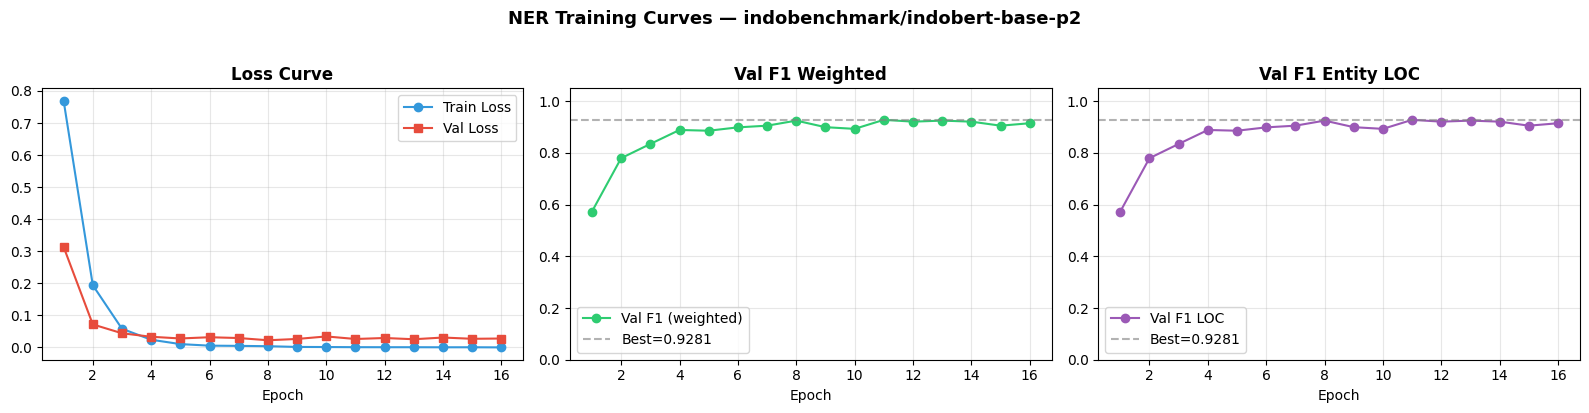


  Best Val F1 LOC  : 0.9281 (epoch 11)
  Stopped at epoch : 16/20
  STATUS: SANGAT BAIK — siap deploy


In [14]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

epochs_train, train_losses = [], []
epochs_eval, eval_losses   = [], []
epochs_f1, eval_f1s        = [], []
epochs_loc, eval_loc_f1s   = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        epochs_train.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        epochs_eval.append(entry["epoch"])
        eval_losses.append(entry["eval_loss"])
        eval_f1s.append(entry.get("eval_f1", 0))
        eval_loc_f1s.append(entry.get("eval_f1_LOC", 0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_train, train_losses, label="Train Loss", color="#3498db", marker="o")
axes[0].plot(epochs_eval,  eval_losses,  label="Val Loss",   color="#e74c3c", marker="s")
axes[0].set_title("Loss Curve", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_eval, eval_f1s, label="Val F1 (weighted)", color="#2ecc71", marker="o")
if eval_f1s:
    axes[1].axhline(max(eval_f1s), color="gray", linestyle="--", alpha=0.6,
                    label=f"Best={max(eval_f1s):.4f}")
axes[1].set_title("Val F1 Weighted", fontweight="bold")
axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_eval, eval_loc_f1s, label="Val F1 LOC", color="#9b59b6", marker="o")
if eval_loc_f1s:
    axes[2].axhline(max(eval_loc_f1s), color="gray", linestyle="--", alpha=0.6,
                    label=f"Best={max(eval_loc_f1s):.4f}")
axes[2].set_title("Val F1 Entity LOC", fontweight="bold")
axes[2].set_ylim(0, 1.05); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f"NER Training Curves — {CONFIG['model_name']}", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
best_f1_loc = max(eval_loc_f1s) if eval_loc_f1s else 0
best_epoch  = (eval_loc_f1s.index(best_f1_loc) + 1) if eval_loc_f1s else 0
stopped_at  = len(eval_losses)
print(f"  Best Val F1 LOC  : {best_f1_loc:.4f} (epoch {best_epoch})")
print(f"  Stopped at epoch : {stopped_at}/{CONFIG['num_epochs']}")
if best_f1_loc >= 0.80: print("  STATUS: SANGAT BAIK — siap deploy")
elif best_f1_loc >= 0.65: print("  STATUS: BAIK — bisa ditingkatkan dengan data augmentasi")
else: print("  STATUS: PERLU REVIEW")
print("=" * 60)


## Cell 15 · Evaluasi Test Set (Best Checkpoint)

In [15]:
print("Mengevaluasi model terbaik pada test set...\n")
test_metrics = trainer.evaluate(eval_dataset=test_tok)

print("=" * 60)
print("HASIL EVALUASI — TEST SET")
print("=" * 60)
for k, v in test_metrics.items():
    print(f"  {k:<35} : {v}")
print("=" * 60)

raw_pred  = trainer.predict(test_tok)
pred_ids  = np.argmax(raw_pred.predictions, axis=-1)
label_ids = raw_pred.label_ids

true_labels_report, true_preds_report = [], []
for pred_seq, label_seq in zip(pred_ids, label_ids):
    tl, tp = [], []
    for p, l in zip(pred_seq, label_seq):
        if l == -100: continue
        tl.append(ID2LABEL[l])
        tp.append(ID2LABEL[p])
    true_labels_report.append(tl)
    true_preds_report.append(tp)

print("\nClassification Report (seqeval, span-level):")
print(seqeval_report(true_labels_report, true_preds_report, zero_division=0))


Mengevaluasi model terbaik pada test set...



HASIL EVALUASI — TEST SET
  eval_loss                           : 0.028245074674487114
  eval_precision                      : 0.908
  eval_recall                         : 0.9737
  eval_f1                             : 0.9397
  eval_f1_LOC                         : 0.9397
  eval_precision_LOC                  : 0.908
  eval_recall_LOC                     : 0.9737
  eval_runtime                        : 0.4978
  eval_samples_per_second             : 222.967
  eval_steps_per_second               : 4.017
  epoch                               : 16.0

Classification Report (seqeval, span-level):
              precision    recall  f1-score   support

         LOC       0.91      0.97      0.94       152

   micro avg       0.91      0.97      0.94       152
   macro avg       0.91      0.97      0.94       152
weighted avg       0.91      0.97      0.94       152



## Cell 16 · Analisis Error (Confusion Matrix + Contoh Salah)

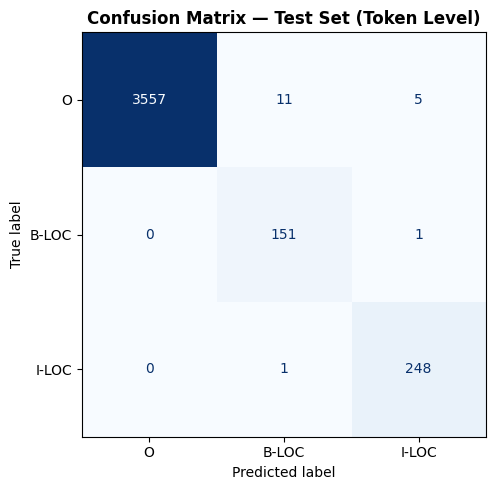


--- Contoh Kalimat dengan Kesalahan ---
  Tokens : ['Warga', 'Wonosari', 'Gunungkidul', 'sini', 'di', 'sekitar', 'sepanjang', 'Jalan', 'Parangtritis', 'KM', '12', 'rame', 'ngomongin', 'bau', 'sampah', 'yang', 'makin', 'hari', 'makin', 'bikin', 'ga', 'nyaman', '.', 'Belum', 'sampe', 'level', 'darurat', 'tapi', 'udah', 'mengganggu', 'banget', 'aktivitas', 'sehari-hari', '.', 'Tolong', 'segera', 'diangkut', '.']
  True   : ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
  Pred   : ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O']

  Tokens : ['Aduh', 'ini', 'darurat', 'banget', ',', 'di', 'dekat', 'dusun', 'Karang', 'Ploso', 'Pa

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

flat_preds = [p for seq in true_preds_report for p in seq]
flat_trues = [t for seq in true_labels_report for t in seq]

label_names = ["O", "B-LOC", "I-LOC"]
cm = confusion_matrix(flat_trues, flat_preds, labels=label_names)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Test Set (Token Level)", fontweight="bold")
plt.tight_layout(); plt.show()

print("\n--- Contoh Kalimat dengan Kesalahan ---")
shown = 0
for sent, preds, trues in zip(test_sents, true_preds_report, true_labels_report):
    if preds != trues and shown < 5:
        tokens = [t for t, _ in sent[:len(trues)]]
        print(f"  Tokens : {tokens}")
        print(f"  True   : {trues}")
        print(f"  Pred   : {preds}\n")
        shown += 1


## Cell 17 · Inferensi Sanity Check

Uji khusus kasus bermasalah: semua casing, boundary angka/singkatan.


In [17]:
from transformers import pipeline as hf_pipeline

ner_pipeline = hf_pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=0 if DEVICE.type == "cuda" else -1,
)


def run_ner_inference(text: str):
    results   = ner_pipeline(text)
    loc_spans = [r for r in results if r["entity_group"] == "LOC"]
    print(f"  Input : {text}")
    if loc_spans:
        locs = [f"'{r['word']}' ({r['score']:.2f})" for r in loc_spans]
        print(f"  LOC   : {', '.join(locs)}")
    else:
        print("  LOC   : (tidak terdeteksi)")
    print()


print("=" * 70)
print("SANITY CHECK — Model harus detect LOC untuk SEMUA casing di bawah ini")
print("=" * 70)
print()

test_cases = [
    # ── Kasus casing (ini yang bermasalah di notebook sebelumnya) ──────────
    ("Mau nanya jadwal truk sampah di Jalan Kaliurang KM 8 hari apa saja",
     "HARAPAN: 'Jalan Kaliurang KM 8'"),
    ("mau nanya jadwal truk sampah di jalan kaliurang km 8 hari apa saja",
     "HARAPAN: 'jalan kaliurang km 8'  [all lowercase]"),
    ("MINTA INFO JADWAL SAMPAH DI JALAN KALIURANG KM 8",
     "HARAPAN: 'JALAN KALIURANG KM 8'  [all uppercase]"),

    # ── Kasus boundary angka & singkatan ─────────────────────────────────
    ("Sampah menumpuk di jalan kaliurang km 10 sudah tiga hari tidak diangkut",
     "HARAPAN: 'jalan kaliurang km 10'"),
    ("di jalan Kenanga RT 02 RW 01 Umbulharjo ada tumpukan sampah besar",
     "HARAPAN: 'jalan Kenanga RT 02 RW 01 Umbulharjo'"),
    ("gawat banget ini jl Magelang KM 7 Sleman dekat perumahan",
     "HARAPAN: 'jl Magelang KM 7 Sleman'"),

    # ── Kasus umum ──────────────────────────────────────────────────────
    ("Woi darurat tumpukan sampah di depan SDN Condong Catur sudah meluber",
     "HARAPAN: 'SDN Condong Catur'"),
    ("Pak tolong cek TPS di belakang Pasar Demangan Gondokusuman bau banget",
     "HARAPAN: 'Pasar Demangan Gondokusuman'"),
    ("Air lindi dari TPS Piyungan mengalir ke Kali Gajahwong dan Kali Code",
     "HARAPAN: 'TPS Piyungan', 'Kali Gajahwong', 'Kali Code'"),
    ("Tidak ada sampah di sini",
     "HARAPAN: (tidak terdeteksi)"),
]

for text, harapan in test_cases:
    print(f"  [{harapan}]")
    run_ner_inference(text)


SANITY CHECK — Model harus detect LOC untuk SEMUA casing di bawah ini

  [HARAPAN: 'Jalan Kaliurang KM 8']
  Input : Mau nanya jadwal truk sampah di Jalan Kaliurang KM 8 hari apa saja
  LOC   : 'jalan kaliurang km 8' (1.00)

  [HARAPAN: 'jalan kaliurang km 8'  [all lowercase]]
  Input : mau nanya jadwal truk sampah di jalan kaliurang km 8 hari apa saja
  LOC   : 'jalan kaliurang km 8' (1.00)

  [HARAPAN: 'JALAN KALIURANG KM 8'  [all uppercase]]
  Input : MINTA INFO JADWAL SAMPAH DI JALAN KALIURANG KM 8
  LOC   : 'jalan kaliurang km 8' (1.00)

  [HARAPAN: 'jalan kaliurang km 10']
  Input : Sampah menumpuk di jalan kaliurang km 10 sudah tiga hari tidak diangkut
  LOC   : 'jalan kaliurang km 10' (1.00)

  [HARAPAN: 'jalan Kenanga RT 02 RW 01 Umbulharjo']
  Input : di jalan Kenanga RT 02 RW 01 Umbulharjo ada tumpukan sampah besar
  LOC   : 'jalan kenanga rt 02 rw 01 umbulharjo' (1.00)

  [HARAPAN: 'jl Magelang KM 7 Sleman']
  Input : gawat banget ini jl Magelang KM 7 Sleman dekat perumahan

## Cell 18 · Simpan Model & Artefak

In [18]:
SAVE_DIR = CONFIG["output_dir"]
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model + tokenizer → {SAVE_DIR}/")

metadata = {
    "task"              : "named-entity-recognition",
    "language"          : "id",
    "base_model"        : CONFIG["model_name"],
    "architecture"      : "BERT (indobert-base-p2) + WeightedLossTrainer",
    "entities"          : ["LOC"],
    "label2id"          : CONFIG["label2id"],
    "id2label"          : {str(k): v for k, v in ID2LABEL.items()},
    "max_length"        : CONFIG["max_length"],
    "do_lower_case"     : True,
    "tokenizer_type"    : type(tokenizer).__name__,
    "train_sentences"   : len(train_sents),
    "val_sentences"     : len(val_sents),
    "test_sentences"    : len(test_sents),
    "split"             : "80/10/10 stratified",
    "loss_function"     : "WeightedCrossEntropyLoss",
    "class_weights"     : {
        "O"     : float(CLASS_WEIGHTS[0]),
        "B-LOC" : float(CLASS_WEIGHTS[1]),
        "I-LOC" : float(CLASS_WEIGHTS[2]),
    },
    "learning_rate"     : CONFIG["learning_rate"],
    "batch_size"        : CONFIG["batch_size"],
    "fix_alignment"     : "Switched ALBERT→BERT WordPiece for reliable word_ids()",
    "fix_class_imbalance": "WeightedLossTrainer with sqrt inverse freq weights",
    "fix_casing"        : "do_lower_case=True, indobert-base-p2 is uncased",
    "test_f1_LOC"       : test_metrics.get("eval_f1_LOC", None),
}
with open(os.path.join(SAVE_DIR, "training_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"Metadata → {SAVE_DIR}/training_metadata.json")

print("""
\n--- Cara Load Ulang ---
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

model = AutoModelForTokenClassification.from_pretrained(SAVE_DIR)
tok   = AutoTokenizer.from_pretrained(SAVE_DIR)
pipe  = pipeline("token-classification", model=model, tokenizer=tok,
                 aggregation_strategy="simple")
""")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + tokenizer → /kaggle/working/ner_bert_uncased_v2/
Metadata → /kaggle/working/ner_bert_uncased_v2/training_metadata.json


--- Cara Load Ulang ---
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

model = AutoModelForTokenClassification.from_pretrained(SAVE_DIR)
tok   = AutoTokenizer.from_pretrained(SAVE_DIR)
pipe  = pipeline("token-classification", model=model, tokenizer=tok,
                 aggregation_strategy="simple")

